# 📝 Frequency-Based Stopword Generator
### Romanized Sylheti Hate Speech Dataset

This notebook builds a **data-driven stopword list** by:
1. Counting how often every word appears in the corpus
2. Splitting frequency by **Hate vs Non-Hate** label
3. Computing a **hate_ratio** per word
4. Auto-filtering words that carry **no discriminative signal** as stopwords
5. Saving the final list to Google Drive

## 📦 1. Install & Import

In [ ]:
import pandas as pd
import re
import os
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print('✅ Libraries loaded')

✅ Libraries loaded


## 📂 2. Mount Google Drive & Load Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ── Update this path to your CSV location in Drive ────────────────────────────
CSV_PATH = '/content/drive/MyDrive/SylHate.csv'  # <-- UPDATE

df = pd.read_csv(CSV_PATH)
df = df[['Sylhaty_Romanize', 'Label']].dropna()
df = df[df['Label'].isin([0, 1, 0.0, 1.0])].copy()
df['Label'] = df['Label'].astype(int)

print(f'Dataset shape : {df.shape}')
print(f'Label counts  :\n{df["Label"].value_counts()}')
df.head()

Dataset shape : (7049, 2)
Label counts  :
Label
1    3779
0    3270
Name: count, dtype: int64


,Sylhaty_Romanize,Label
0,ino BNP r hat ase 1 ta aua manush r boro chur,1
1,furita bemar pagol,0
2,obosshoi koimu,0
3,madarchod hokol chobir chain katle sobi upload...,1
4,DCr roomo j manushe camerata lagaise tare guen...,0


## 🧹 3. Basic Clean (Letters Only)

In [ ]:
def basic_clean(text):
    if not isinstance(text, str):
        return ''
    text = re.sub(r'http\S+|www\.\S+', '', text)   # remove URLs
    text = re.sub(r'#\w+|@\w+', '', text)           # remove hashtags & mentions
    text = re.sub(r'[^a-zA-Z\s]', '', text)         # keep only letters
    text = text.lower().strip()
    return text

df['clean'] = df['Sylhaty_Romanize'].apply(basic_clean)

print('Before:', df['Sylhaty_Romanize'].iloc[3])
print('After :', df['clean'].iloc[3])

Before: madarchod hokol chobir chain katle sobi upload dis na.
After : madarchod hokol chobir chain katle sobi upload dis na


## 📊 4. Word Frequency Count — Full Corpus

In [ ]:
all_words = []
for text in df['clean']:
    all_words.extend(text.split())

word_freq = Counter(all_words)
freq_df   = pd.DataFrame(word_freq.items(), columns=['word', 'frequency'])
freq_df   = freq_df.sort_values('frequency', ascending=False).reset_index(drop=True)

print(f'Total unique words : {len(freq_df):,}')
print(f'Total word tokens  : {sum(freq_df.frequency):,}')
print(f'\nTop 50 most frequent words:')
print(freq_df.head(50).to_string(index=False))

Total unique words : 13,370
Total word tokens  : 67,372

Top 50 most frequent words:
  word  frequency
    na       1120
     o        641
  kita        616
    or        540
     e        539
    re        483
    ni        435
    ar        420
   tor        396
   ami        380
  lagi        360
     r        336
   ita        332
  amar        319
  bala        308
   tui        306
   nai        288
   nay        260
    oy        253
 video        252
  ekta        240
   fua        238
    to        234
  kori        232
  hala        228
  magi        216
  loge        206
  bhai        205
dorkar        203
 tumar        199
  furi        198
  taki        196
   dia        190
   ase        186
  tumi        183
manush        179
    ou        176
 koria        175
     j        171
  boro        170
    ow        169
   oto        167
  kora        164
  lage        161
   tar        158
 halar        156
    je        155
    go        155
  oibo        155
    ta        1

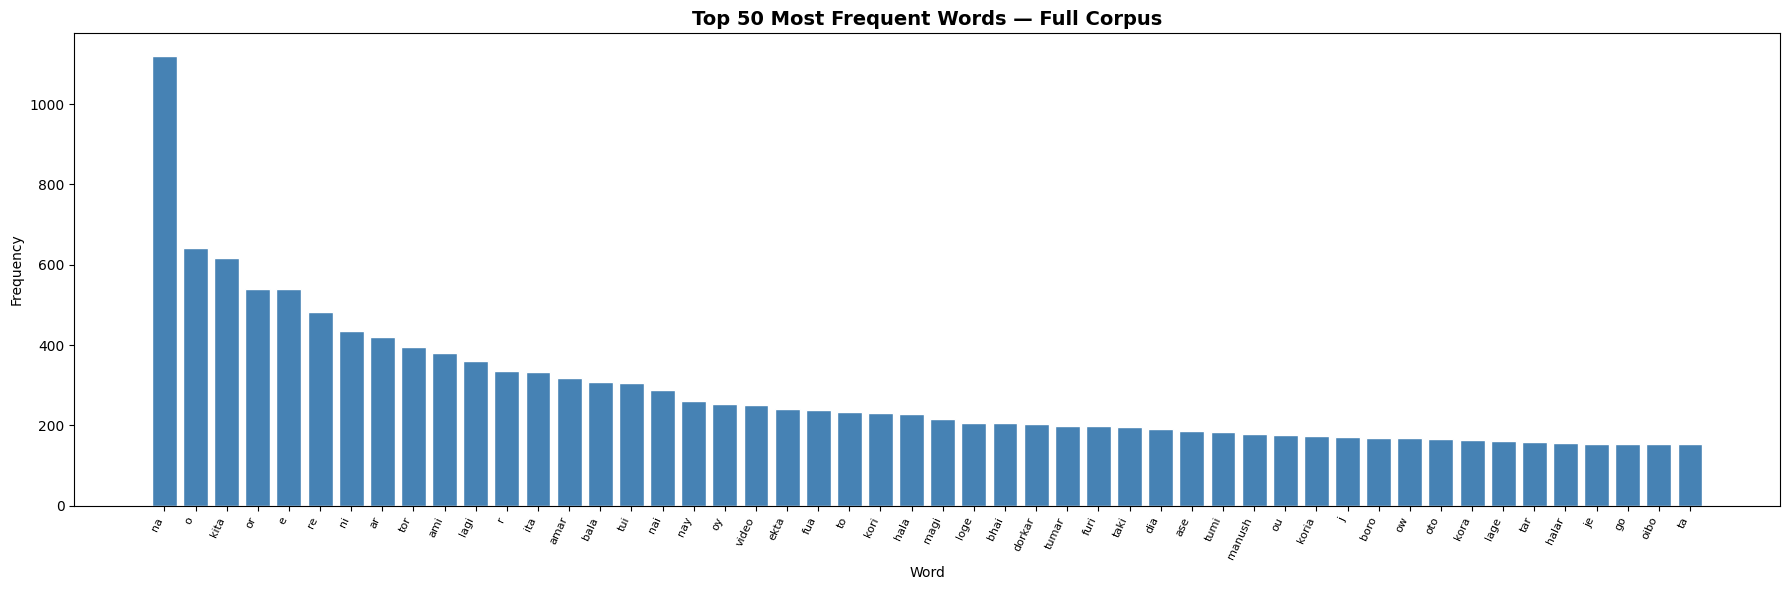

✅ Saved → word_frequency_top50.png


In [ ]:
# ── Bar chart: Top 50 most frequent words ─────────────────────────────────────
TOP_N = 50

fig, ax = plt.subplots(figsize=(18, 6))
ax.bar(freq_df['word'][:TOP_N], freq_df['frequency'][:TOP_N],
       color='steelblue', edgecolor='white')
ax.set_title(f'Top {TOP_N} Most Frequent Words — Full Corpus',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Word')
ax.set_ylabel('Frequency')
plt.xticks(rotation=65, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/word_frequency_top50.png', dpi=150)
plt.show()
print('✅ Saved → word_frequency_top50.png')

## ⚖️ 5. Frequency Split — Hate vs Non-Hate

In [ ]:
hate_words    = []
nonhate_words = []

for _, row in df.iterrows():
    tokens = row['clean'].split()
    if row['Label'] == 1:
        hate_words.extend(tokens)
    else:
        nonhate_words.extend(tokens)

hate_freq    = Counter(hate_words)
nonhate_freq = Counter(nonhate_words)

hate_df    = pd.DataFrame(hate_freq.items(),    columns=['word', 'hate_freq'])
nonhate_df = pd.DataFrame(nonhate_freq.items(), columns=['word', 'nonhate_freq'])

# Merge both
compare_df = pd.merge(hate_df, nonhate_df, on='word', how='outer').fillna(0)
compare_df['hate_freq']    = compare_df['hate_freq'].astype(int)
compare_df['nonhate_freq'] = compare_df['nonhate_freq'].astype(int)
compare_df['total_freq']   = compare_df['hate_freq'] + compare_df['nonhate_freq']
compare_df['hate_ratio']   = compare_df['hate_freq'] / (compare_df['total_freq'] + 1e-9)
compare_df = compare_df.sort_values('total_freq', ascending=False).reset_index(drop=True)

print('Top 30 words — Hate vs Non-Hate:')
print(compare_df.head(30).to_string(index=False))

Top 30 words — Hate vs Non-Hate:
  word  hate_freq  nonhate_freq  total_freq  hate_ratio
    na        524           596        1120    0.467857
     o        314           327         641    0.489860
  kita        310           306         616    0.503247
    or        255           285         540    0.472222
     e        305           234         539    0.565863
    re        275           208         483    0.569358
    ni        253           182         435    0.581609
    ar        198           222         420    0.471429
   tor        328            68         396    0.828283
   ami        107           273         380    0.281579
  lagi        147           213         360    0.408333
     r        187           149         336    0.556548
   ita        184           148         332    0.554217
  amar        134           185         319    0.420063
  bala        104           204         308    0.337662
   tui        235            71         306    0.767974
   nai        1

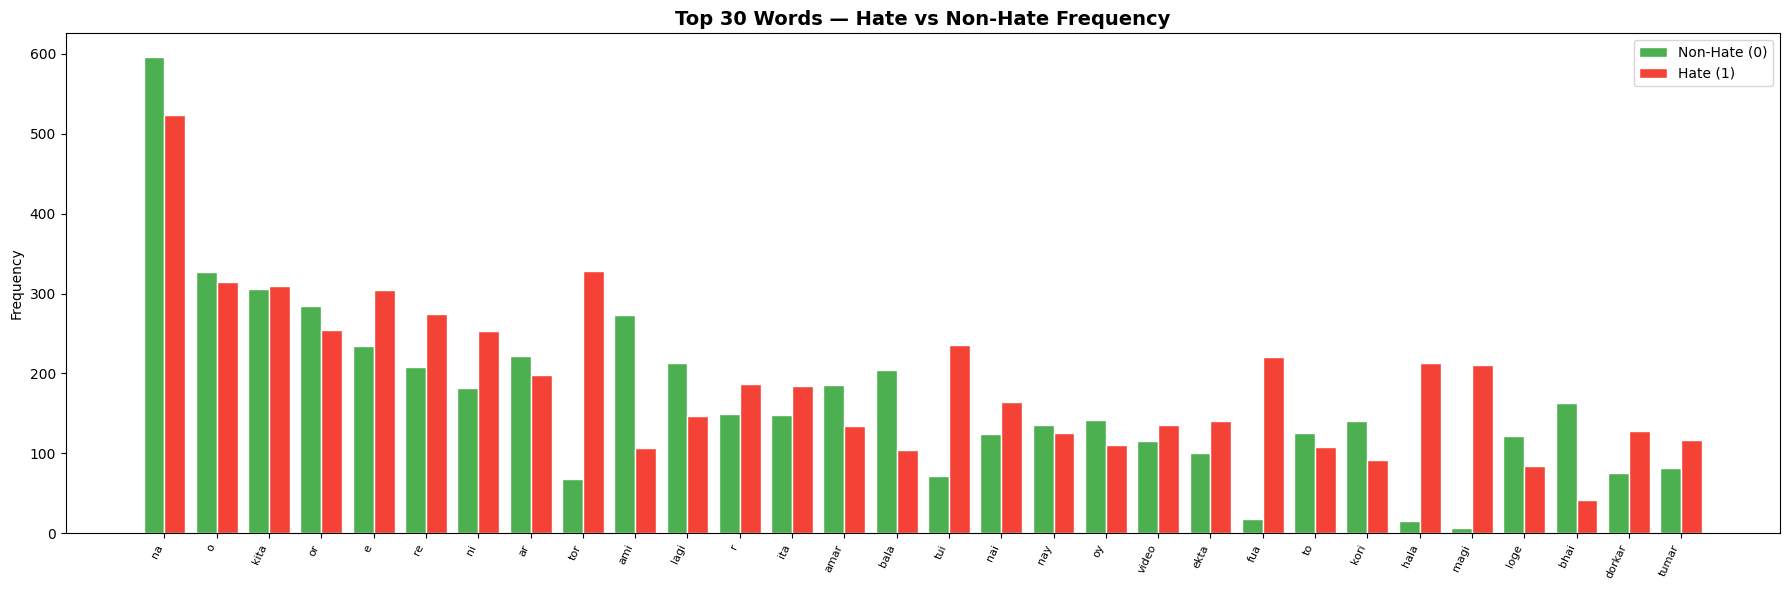

✅ Saved → hate_vs_nonhate_frequency.png


In [ ]:
# ── Grouped bar chart: Top 30 hate vs non-hate frequency ─────────────────────
top30 = compare_df.head(30)
x     = range(len(top30))
width = 0.4

fig, ax = plt.subplots(figsize=(18, 6))
ax.bar([i - width/2 for i in x], top30['nonhate_freq'], width,
       label='Non-Hate (0)', color='#4CAF50', edgecolor='white')
ax.bar([i + width/2 for i in x], top30['hate_freq'],    width,
       label='Hate (1)',     color='#F44336', edgecolor='white')

ax.set_xticks(list(x))
ax.set_xticklabels(top30['word'], rotation=65, ha='right', fontsize=8)
ax.set_title('Top 30 Words — Hate vs Non-Hate Frequency', fontsize=14, fontweight='bold')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/hate_vs_nonhate_frequency.png', dpi=150)
plt.show()
print('✅ Saved → hate_vs_nonhate_frequency.png')

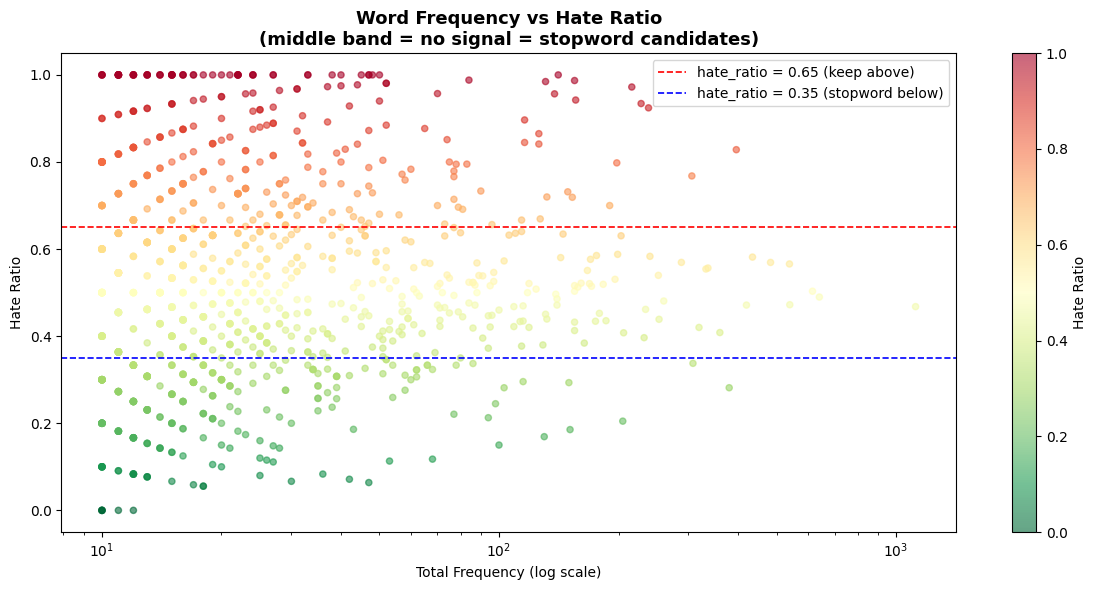

✅ Saved → hate_ratio_scatter.png


In [ ]:
# ── Hate ratio scatter: frequency vs hate_ratio ───────────────────────────────
# Words in the middle (ratio ~0.5) = no signal = stopword candidates
# Words near 1.0 = strong hate signal = KEEP

plot_df = compare_df[compare_df['total_freq'] >= 10].copy()

fig, ax = plt.subplots(figsize=(12, 6))
scatter = ax.scatter(
    plot_df['total_freq'],
    plot_df['hate_ratio'],
    c=plot_df['hate_ratio'],
    cmap='RdYlGn_r',
    alpha=0.6, s=20
)
ax.axhline(0.65, color='red',  linestyle='--', linewidth=1.2, label='hate_ratio = 0.65 (keep above)')
ax.axhline(0.35, color='blue', linestyle='--', linewidth=1.2, label='hate_ratio = 0.35 (stopword below)')
ax.set_xscale('log')
ax.set_xlabel('Total Frequency (log scale)')
ax.set_ylabel('Hate Ratio')
ax.set_title('Word Frequency vs Hate Ratio\n(middle band = no signal = stopword candidates)',
             fontsize=13, fontweight='bold')
ax.legend()
plt.colorbar(scatter, ax=ax, label='Hate Ratio')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/hate_ratio_scatter.png', dpi=150)
plt.show()
print('✅ Saved → hate_ratio_scatter.png')

## 🎯 6. Filter Stopwords by Frequency + Hate Ratio

**Logic:**
- `FREQ_THRESHOLD` — word must appear at least this many times to be considered
- `HATE_RATIO_MAX` — words with hate_ratio **below** this are neutral → stopword
- Words with hate_ratio **above** this lean toward hate content → **keep as signal**

In [ ]:
# ── Tune these two thresholds ─────────────────────────────────────────────────
FREQ_THRESHOLD = 50     # min total occurrences to be a candidate
HATE_RATIO_MAX = 0.65   # words with ratio <= this are stopwords
# ─────────────────────────────────────────────────────────────────────────────

candidates_df = compare_df[compare_df['total_freq'] >= FREQ_THRESHOLD].copy()

auto_stopwords_df = candidates_df[
    candidates_df['hate_ratio'] <= HATE_RATIO_MAX
].sort_values('total_freq', ascending=False)

signal_words_df = candidates_df[
    candidates_df['hate_ratio'] > HATE_RATIO_MAX
].sort_values('hate_ratio', ascending=False)

print(f'Candidate words (freq >= {FREQ_THRESHOLD})    : {len(candidates_df)}')
print(f'Auto stopwords  (hate_ratio <= {HATE_RATIO_MAX}) : {len(auto_stopwords_df)}')
print(f'Signal words    (hate_ratio >  {HATE_RATIO_MAX}) : {len(signal_words_df)} (DO NOT remove these!)')

print('\n--- STOPWORD CANDIDATES ---')
print(auto_stopwords_df[['word','total_freq','hate_freq','nonhate_freq','hate_ratio']].to_string(index=False))

print('\n--- SIGNAL WORDS (keep!) ---')
print(signal_words_df[['word','total_freq','hate_freq','nonhate_freq','hate_ratio']].head(20).to_string(index=False))

Candidate words (freq >= 50)    : 211
Auto stopwords  (hate_ratio <= 0.65) : 163
Signal words    (hate_ratio >  0.65) : 48 (DO NOT remove these!)

--- STOPWORD CANDIDATES ---
      word  total_freq  hate_freq  nonhate_freq  hate_ratio
        na        1120        524           596    0.467857
         o         641        314           327    0.489860
      kita         616        310           306    0.503247
        or         540        255           285    0.472222
         e         539        305           234    0.565863
        re         483        275           208    0.569358
        ni         435        253           182    0.581609
        ar         420        198           222    0.471429
       ami         380        107           273    0.281579
      lagi         360        147           213    0.408333
         r         336        187           149    0.556548
       ita         332        184           148    0.554217
      amar         319        134           1

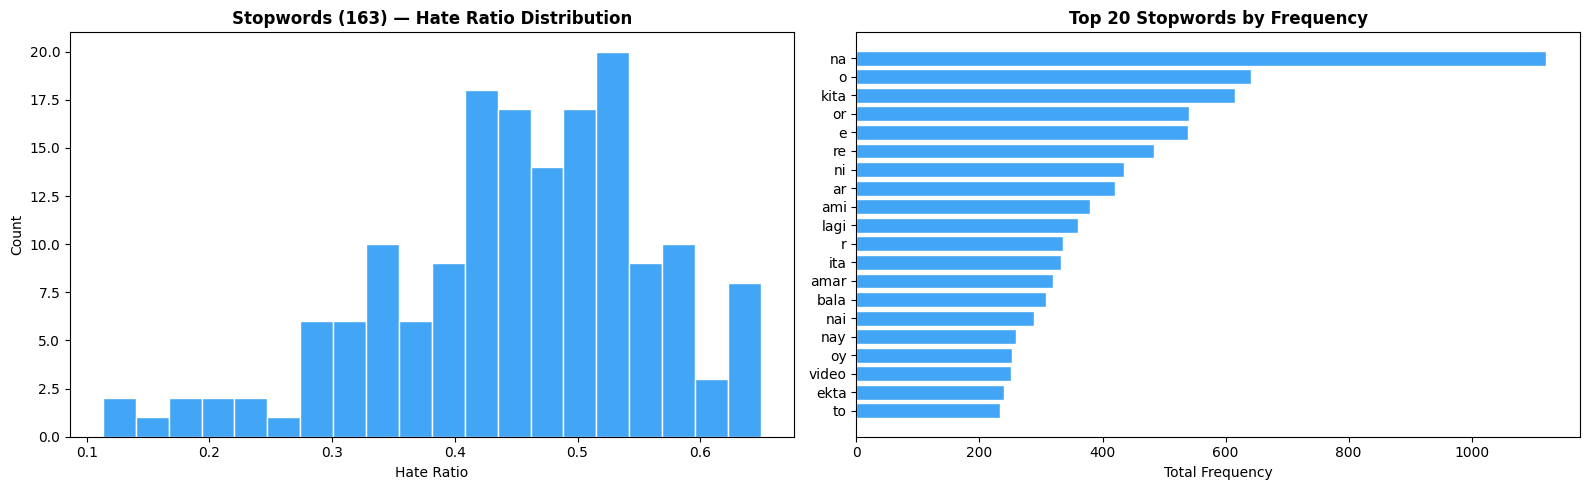

✅ Saved → stopwords_analysis.png


In [ ]:
# ── Visualize: stopwords vs signal words by hate_ratio ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Stopwords — hate ratio distribution
axes[0].hist(auto_stopwords_df['hate_ratio'], bins=20, color='#42A5F5', edgecolor='white')
axes[0].set_title(f'Stopwords ({len(auto_stopwords_df)}) — Hate Ratio Distribution',
                  fontweight='bold')
axes[0].set_xlabel('Hate Ratio')
axes[0].set_ylabel('Count')

# Top 20 stopwords by frequency
top_sw = auto_stopwords_df.head(20)
axes[1].barh(top_sw['word'], top_sw['total_freq'], color='#42A5F5', edgecolor='white')
axes[1].invert_yaxis()
axes[1].set_title('Top 20 Stopwords by Frequency', fontweight='bold')
axes[1].set_xlabel('Total Frequency')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/stopwords_analysis.png', dpi=150)
plt.show()
print('✅ Saved → stopwords_analysis.png')

## 💾 7. Save Stopwords & Frequency Analysis to Drive

In [ ]:
# ── Output paths ──────────────────────────────────────────────────────────────
STOPWORD_PATH = '/content/drive/MyDrive/sylheti_stopwords.txt'       # <-- UPDATE if needed
FREQ_CSV_PATH = '/content/drive/MyDrive/sylheti_word_frequency.csv'  # <-- UPDATE if needed

# Save stopword list
final_stopwords = sorted(set(auto_stopwords_df['word'].tolist()))
with open(STOPWORD_PATH, 'w', encoding='utf-8') as f:
    for word in final_stopwords:
        f.write(word + '\n')

# Save full frequency analysis CSV
compare_df.to_csv(FREQ_CSV_PATH, index=False)

print(f'✅ Saved {len(final_stopwords)} stopwords       → {STOPWORD_PATH}')
print(f'✅ Saved frequency analysis CSV → {FREQ_CSV_PATH}')
print(f'\nFinal stopword list:')
print(final_stopwords)

✅ Saved 163 stopwords       → /content/drive/MyDrive/sylheti_stopwords.txt
✅ Saved frequency analysis CSV → /content/drive/MyDrive/sylheti_word_frequency.csv

Final stopword list:
['a', 'abar', 'afnar', 'afne', 'age', 'aij', 'akta', 'allah', 'amar', 'amare', 'ami', 'amr', 'amra', 'amrar', 'ar', 'aro', 'ase', 'asil', 'ba', 'bad', 'bade', 'bai', 'bala', 'bangladesh', 'bar', 'beshi', 'bhai', 'bhondo', 'bichar', 'biya', 'boin', 'boro', 'bout', 'chai', 'comment', 'deki', 'dekia', 'deoa', 'dewa', 'dile', 'din', 'diya', 'dol', 'dorkar', 'e', 'ek', 'ekhon', 'ekon', 'ekta', 'er', 'eta', 'fashi', 'gese', 'giya', 'go', 'he', 'ikta', 'ila', 'ita', 'itar', 'j', 'jane', 'jar', 'jay', 'je', 'jeno', 'jodi', 'judi', 'k', 'kali', 'kam', 'karon', 'kase', 'ke', 'kene', 'keu', 'khub', 'ki', 'kicchu', 'kila', 'kintu', 'kita', 'koi', 'kora', 'korar', 'kore', 'kori', 'koria', 'koro', 'korse', 'korte', 'korto', 'kota', 'kotha', 'koto', 'kun', 'kuno', 'lagbo', 'lage', 'lagi', 'lakhan', 'loge', 'loia', 'loiya', 

## 🔄 8. Load & Use in Your Preprocessing Pipeline

In [ ]:
# ── Load stopwords from Drive ─────────────────────────────────────────────────
with open(STOPWORD_PATH, 'r', encoding='utf-8') as f:
    BANGLISH_STOPWORDS = set(f.read().splitlines())

print(f'✅ Loaded {len(BANGLISH_STOPWORDS)} stopwords')

# ── Full preprocessing function with loaded stopwords ─────────────────────────
def preprocess(text: str) -> str:
    if not isinstance(text, str):
        return ''
    # Step 1 – Noise removal
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'#\w+|@\w+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Step 2 – Case folding
    text = text.lower()
    # Step 3 – Repeated character reduction (3+ → 2)
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)
    # Step 4 – Stopword filtering (data-driven list)
    tokens = [t for t in text.split() if t not in BANGLISH_STOPWORDS and len(t) > 1]
    return ' '.join(tokens)

# Quick test
sample = df['Sylhaty_Romanize'].iloc[5]
print(f'\nOriginal  : {sample}')
print(f'Processed : {preprocess(sample)}')

✅ Loaded 163 stopwords

Original  : hala luiccha 
Processed : hala luiccha


In [ ]:
# ── Apply to full dataset & preview ───────────────────────────────────────────
df['text_processed'] = df['Sylhaty_Romanize'].apply(preprocess)

print('Sample processed texts:')
df[['Sylhaty_Romanize', 'text_processed', 'Label']].head(10)

Sample processed texts:


,Sylhaty_Romanize,text_processed,Label
0,ino BNP r hat ase 1 ta aua manush r boro chur,ino bnp hat aua chur,1
1,furita bemar pagol,furita bemar pagol,0
2,obosshoi koimu,obosshoi koimu,0
3,madarchod hokol chobir chain katle sobi upload...,madarchod hokol chobir chain katle sobi upload...,1
4,DCr roomo j manushe camerata lagaise tare guen...,dcr roomo manushe camerata lagaise guenda bibh...,0
5,hala luiccha,hala luiccha,1
6,ainor bichar ouk,ainor,0
7,likhito boktobbo deoar lagi baddo kora or.,likhito boktobbo deoar baddo,0
8,ahare kita korle ita � chiro jahannami tui,ahare korle chiro jahannami tui,1
9,ha ha ha moja failam,ha ha ha failam,0


## ✅ Summary

| File saved | Description |
|---|---|
| `sylheti_stopwords.txt` | Final data-driven stopword list |
| `sylheti_word_frequency.csv` | Full word freq table with hate_ratio |
| `word_frequency_top50.png` | Top 50 words bar chart |
| `hate_vs_nonhate_frequency.png` | Hate vs Non-Hate grouped bar chart |
| `hate_ratio_scatter.png` | Frequency vs hate_ratio scatter |
| `stopwords_analysis.png` | Stopword distribution charts |

**To tune the stopword list:** adjust `FREQ_THRESHOLD` and `HATE_RATIO_MAX` in Section 6 and re-run.